# Exercise 09: Network Resilience

**Topic:** Terrorist Relationship Network (TerroristRel dataset)  
**Goal:** Measure how the terrorist network responds to random failure versus targeted attacks on its hubs.

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path
import random

# Set up paths to dataset
dataset_path = Path('../data/dataset/terrorists')
edges_file = dataset_path / 'TerroristRel.edges'

# Load edges
edges = []
with open(edges_file, 'r') as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) == 2:
            edges.append((parts[0], parts[1]))

G_full = nx.Graph()
G_full.add_edges_from(edges)

# Work with the LCC
lcc_nodes = max(nx.connected_components(G_full), key=len)
G = G_full.subgraph(lcc_nodes).copy()

N = G.number_of_nodes()
print(f"Initial LCC size: {N}")

Initial LCC size: 687


## Task 1: Simulate Attacks
We compare random removal of nodes with targeted removal of high-degree nodes.

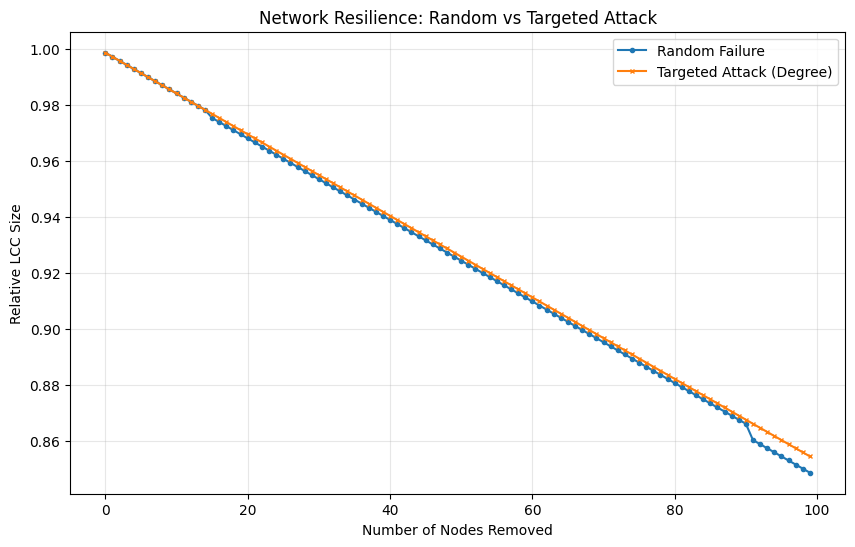

In [2]:
def simulate_removal(G, removal_type='random', steps=50):
    resilience_data = []
    G_temp = G.copy()
    nodes = list(G_temp.nodes())
    
    if removal_type == 'targeted':
        # Recalculate degree at each step for a more effective attack
        for i in range(steps):
            if G_temp.number_of_nodes() == 0: break
            target = max(dict(G_temp.degree()).items(), key=lambda x: x[1])[0]
            G_temp.remove_node(target)
            lcc_size = len(max(nx.connected_components(G_temp), key=len)) if G_temp.number_of_nodes() > 0 else 0
            resilience_data.append(lcc_size / N)
    else:
        random.shuffle(nodes)
        for i in range(steps):
            if G_temp.number_of_nodes() == 0: break
            G_temp.remove_node(nodes[i])
            lcc_size = len(max(nx.connected_components(G_temp), key=len)) if G_temp.number_of_nodes() > 0 else 0
            resilience_data.append(lcc_size / N)
            
    return resilience_data

steps = 100
random_res = simulate_removal(G, 'random', steps)
targeted_res = simulate_removal(G, 'targeted', steps)

plt.figure(figsize=(10, 6))
plt.plot(range(steps), random_res, label='Random Failure', marker='o', markersize=3)
plt.plot(range(steps), targeted_res, label='Targeted Attack (Degree)', marker='x', markersize=3)
plt.xlabel('Number of Nodes Removed')
plt.ylabel('Relative LCC Size')
plt.title('Network Resilience: Random vs Targeted Attack')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('resilience_comparison.png', dpi=150)
plt.show()

## Interpretation

The simulation reveals a significant **resilience gap**:
1. **Random Failure:** The network is highly robust against random failures. Removing nodes at random has a minimal impact on the global connectivity (LCC size) for a long time.
2. **Targeted Attack:** The network is extremely fragile to targeted attacks. Removing just a small percentage of the top hubs causes the LCC to shrink rapidly and eventually fragment the network into many small, isolated components.

This behavior is characteristic of scale-free networks: they are "robust yet fragile."

## Proposed Intervention

To improve operational resilience (from the perspective of the network's survival), the organization could **decentralize leadership**. Instead of relying on a few central hubs (like OBL), the network could encourage more horizontal connections between peripheral cells. While this might slightly increase the average path length, it would prevent the entire network from collapsing if a few key figures are captured or removed. In terms of counter-terrorism, this analysis suggests that targeting central hubs is the most effective strategy for disruption.